# Exercise 2. Analyze words with spaCy
Another way to investigate word distributions is to consider the types of words used in a text, such as whether it contains more nouns than verbs. We can do this with the NLP library [spaCy](https://spacy.io/).

## 2.1 Loading the SpaCy model
Firstly, install the spaCy package in your own notebook:

In [1]:
%pip install spacy


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Now download the spacy model to your notebook:

In [2]:
!python -m spacy download en_core_web_sm 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 11.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


Load your model now:

In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")

(22-spacy-doc-objects)=
## 2.2 spaCy `Doc` objects: Tokenization without Preprocessing
Instead of tokenizing manually like in the previous exercise, the `spaCy` pipeline can turn `chatgpt_text` into a `Doc` object, containing tokens and other linguistic information (no preprocessing needed from us!):

```{figure} ../figures/class1/spacy_pipeline.png
---
name: spacy-pipeline
---
From [spaCy docs](https://spacy.io/usage/processing-pipelines): The `tagger`, `parser`, and `ner` are pipeline components that extract linguistic features. For instance, the `tagger` assigns `part-of-speech` labels to tokens, which you will play with in the next [section](#23-parts-of-speech-analysis).
```

In [4]:
## NB: This code chunk is hidden in the teachbooks interface, but is imported here to re-use variables from 001!
chatgpt_text = """
Title: Distance Learning vs. Attending School In Person: A Comparative Analysis
Education, a cornerstone of human development, has evolved significantly over time. 
With the advent of technology and the challenges posed by the global pandemic, the focus has shifted towards distance learning, a mode that offers flexibility, accessibility, and convenience. 
However, traditional in-person learning remains indispensable for a holistic educational experience. 
This essay will compare and contrast distance learning and attending school in person, highlighting the advantages and disadvantages of each.

Distance learning, primarily facilitated through online platforms, offers a plethora of advantages. 
It provides students with access to a vast array of resources and the ability to learn at their own pace. 
Moreover, it transcends geographical boundaries, allowing students from remote locations to access quality education. 
Nevertheless, distance learning poses challenges related to student engagement, lack of social interaction, and the potential for digital inequity.

On the other hand, attending school in person offers a well-rounded learning experience. In-person learning fosters strong bonds among students, promoting teamwork and collaboration. 
Furthermore, it enables teachers to provide immediate feedback and tailor their teaching methods to the individual needs of students. 
However, traditional classrooms may limit access to resources and impose geographical constraints.

In conclusion, both distance learning and in-person education have their unique advantages and disadvantages. 
Distance learning offers flexibility and accessibility, while in-person learning facilitates social interaction and individualized instruction. 
As education continues to evolve, a hybrid approach that combines the strengths of both methods may prove to be the most effective solution, catering to the diverse needs of students in the 21st century.
"""

student_text = """
A matter of considerable controversy at present is the issue of whether distance-learning should be promoted as much as possible, or rather attending lectures in person should be allowed to take a predominant place in universities because this way of learning is superior than online degrees. From my perspective, online-teaching should be widely used among colleges and universities in terms of convenience and optimizing cost for educational institutions.
To begin with, distance-learning brings significant convenience for students in every corner of the world. In earlier times, students who were tired of commuting had to attend schools nearby, regardless of any differences in teaching facilities, teacher's qualifications or the school reputation. Now, however, students are able to apply for online-courses provided by top-of-the-range universities and colleges worldwide. 
Furthermore, the presence of video conferencing allows a teacher to teach a greater number of students. Consequently, educational institutions are able to optimize costs by increasing teacher-student ratios. Thanks to the economical online-teaching, universities and colleges are able to offer grants for students who have outstanding academic achievements but are unable to attend schools because of financial constrains.
Nevertheless, opponents of online-degrees would argue that attending lectures in person provides students an opportunity to communicate with teachers and other classmates. They further point out that traditional teaching approaches involving discussion and cooperation among students play a significant role in campus life. It is the real interactions and communications in class make education much more attractive.
By way of conclusion, it is my belief that distance-learning will become increasingly important in the future as the pace of life increases. However, discussions and interactions should be held via video conferencing frequently so that the joy of learning would not be diminished.
"""

Let's apply our loaded model (`nlp`) to our text as shown in the figure above: 

In [5]:
chatgpt_doc = nlp(chatgpt_text)

We can extract tokens by iterating over the `chatgpt_doc` object with a `for loop` and accessing each token's `.text` attribute. NOTE that we write `.lower()` to get the token lowercased.

In [6]:
for token in chatgpt_doc: 
    print(token.text.lower()) # access the text of the token in lower-case



title
:
distance
learning
vs.
attending
school
in
person
:
a
comparative
analysis


education
,
a
cornerstone
of
human
development
,
has
evolved
significantly
over
time
.


with
the
advent
of
technology
and
the
challenges
posed
by
the
global
pandemic
,
the
focus
has
shifted
towards
distance
learning
,
a
mode
that
offers
flexibility
,
accessibility
,
and
convenience
.


however
,
traditional
in
-
person
learning
remains
indispensable
for
a
holistic
educational
experience
.


this
essay
will
compare
and
contrast
distance
learning
and
attending
school
in
person
,
highlighting
the
advantages
and
disadvantages
of
each
.



distance
learning
,
primarily
facilitated
through
online
platforms
,
offers
a
plethora
of
advantages
.


it
provides
students
with
access
to
a
vast
array
of
resources
and
the
ability
to
learn
at
their
own
pace
.


moreover
,
it
transcends
geographical
boundaries
,
allowing
students
from
remote
locations
to
access
quality
education
.


nevertheless
,
distance
learning
po

(23-parts-of-speech-analysis)=
## 2.3 Parts of Speech Analysis

As mentioned, `doc` objects contain more than just the tokenized text. 

In this section, we will focus on each token's `.pos_` attribute, which stands for "part-of-speech" and indicates the grammatical category of the word (e.g., noun, verb, conjunction, proper noun, etc.).

```{figure} ../figures/class1/pos-tagging.png
---
name: pos-tag-figure
---
Originally by [Leonie Monigatti](https://towardsdatascience.com/visualizing-part-of-speech-tags-with-nltk-and-spacy-42056fcd777e/)
```

### Your Turn: Creating DFs with POS Information.


:::{admonition} HANDS-ON
:class: red
1. Extract both the tokenized text (`token.text.lower()`) and the parts of speech (`token.pos_`) from both chatgpt and student DOC objects. 
2. Put this information in two pandas df (`student_df` and `chatgpt_df`) it should look something like this:
```
        token     pos
0     distance    NOUN
1     learning    NOUN
2         vs.   CCONJ
3   attending    VERB
4       school    NOUN
...
```

NOTE: 
- Do not forget the `_` for the `pos_` attribute!
- Remember to create both `chatgpt_doc` and `student_doc` in your notebook!
:::

Let's start by importing `pandas` if you haven't already done so (best practice to put it at the top of a notebook)

In [7]:
import pandas as pd # standard convention to abbreviate to "pd" 

#### Solutions
```{admonition} HINT
:class: tip, dropdown

Remember that we can extract token information with a `for loop` as we did above in [section 2.2](22-spacy-doc-objects). We just need to also save this to a list. 

For saving to a list, you might want to take inspiration from how we filtered away stopwords in [section 1.4](14-filtering-stopwords) (this time there is just no conditional "if" needed!).
```

##### Solution 1: For Loop!

In [8]:
# define empty lists 
chatgpt_tokens = []
chatgpt_pos = []

# extract tokens and POS tags
for token in chatgpt_doc:
    # for every token extract text and add to tokens list, repeat for POS
    chatgpt_tokens.append(token.text.lower())
    chatgpt_pos.append(token.pos_)

# make into df 
chatgpt_df = pd.DataFrame({"token": chatgpt_tokens, "pos": chatgpt_pos})

# repeat for student ! remember to make student_doc first!

##### Solution 2: Functions!

In [9]:
def extract_tokens_pos(doc:spacy.tokens.Doc, lower:bool=True) -> tuple[list, list]:
    """
    Extract both tokens and their pos a lists from a spaCy doc. 
    
    If lower equals true, lowercase the text. Defaults to lowering (if you do not specify)
    """
    tokens = [token.text.lower() if lower else token.text for token in doc]
    pos_tags = [token.pos_ for token in doc]

    return tokens, pos_tags

def extract_pos_df(doc:spacy.tokens.Doc, lower:bool=True) -> tuple[list, list]:
    """
    Extract both tokens and their pos a lists from a spaCy doc!
    """
    tokens, pos_tags = extract_tokens_pos(doc, lower=lower)

    df = pd.DataFrame({'token': tokens, 'pos': pos_tags})
    return df

## applying this now!
student_doc = nlp(student_text)
student_df = extract_pos_df(student_doc, lower=True)
chatgpt_df = extract_pos_df(chatgpt_doc, lower=True)


#### Result
You should now have `student_df` and `chatgpt_df`:

In [10]:
print(student_df) 

            token    pos
0              \n  SPACE
1               a    DET
2          matter   NOUN
3              of    ADP
4    considerable    ADJ
..            ...    ...
336           not   PART
337            be    AUX
338    diminished   VERB
339             .  PUNCT
340            \n  SPACE

[341 rows x 2 columns]


In [11]:
print(chatgpt_df)

        token    pos
0          \n  SPACE
1       title   NOUN
2           :  PUNCT
3    distance  PROPN
4    learning  PROPN
..        ...    ...
325       the    DET
326      21st    ADJ
327   century   NOUN
328         .  PUNCT
329        \n  SPACE

[330 rows x 2 columns]


### Adding a Frequency Column and Plotting
Right now, each token is present as a seperate row. But we don't want duplicates - we want something similar to our dataframes resulting from `Counter` in exercise 1. 

We can use `pandas` to create a `frequency` column with the `groupby` and `agg` methods

In [12]:
# group by token and pos, count occurrences, and sort by frequency
chatgpt_agg_df = (
    chatgpt_df.groupby(['token', 'pos'], as_index=False) # as index to keep "token" and "pos" as regular columns
      .agg(frequency=('token', 'count'))  # count tokens per group, 'count' is a keyword argument
      .sort_values('frequency', ascending=False) # sort so most frequent tokens come first
)

student_agg_df = (
    student_df.groupby(['token', 'pos'], as_index=False) 
      .agg(frequency=('token', 'count'))  
      .sort_values('frequency', ascending=False) 
)

Lets plot! Import matplotlib and seaborn if you haven't already:

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

I have modified the function slightly from [section 1.4](14-filtering-stopwords) (solution 3) where `y`, `hue` and `x` are now parameters, you can pass (so that it is not specific to the way we made df's in the last exercise):

In [14]:
# has been modified sligthly from 1.4 (y and hue is now a param)
def plot_frequent_counts(count_df: pd.DataFrame, x=0, y:str="index", n_most_frequent:int=50, title:str = "Word Dist", xlim:int=15, hue:str='index') -> plt.Figure:
    """
    Plots the n highest counts in a count_df

    Xlim to make sure they are the same across plots :)
    """
    plot = sns.catplot(
            data=count_df.head(n=n_most_frequent), 
            x=x, 
            y=y,     
            kind='bar',
            height=7, 
            aspect=2,
            palette="husl",   # rainbow colors
            hue=hue,      # 'y' to force each category to be colored separately or another column name to group colors! e.g., ""
            dodge=False # to ensure bars stay the same width despite more hues
            )     
    plt.title(title)
    plt.xticks(rotation=90)
    plt.xlabel('')
    plt.ylabel('frequency')
    plt.grid(which='major', axis='x', zorder=-1.0)
    plt.xlim(right=xlim)

    return plot.figure # note I Have to write .figures to get the plt.Figure from Seaborn (just how seaborn is setup)

We set `hue = pos` to color by the `parts-of-speech` of the particular token! 

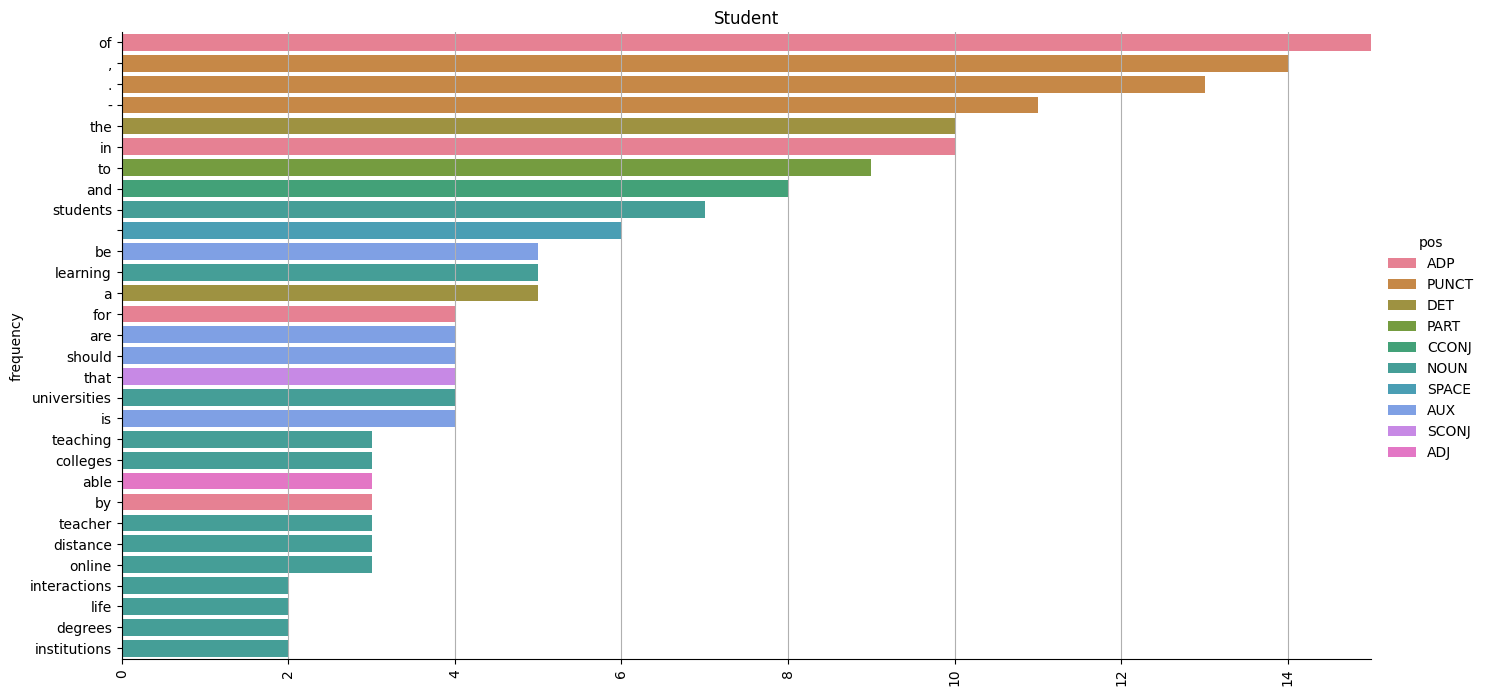

In [15]:
n_most_frequent = 30
plot = plot_frequent_counts(
                            count_df=student_agg_df.head(n_most_frequent), 
                            x = "frequency",
                            y = "token",
                            n_most_frequent=n_most_frequent, 
                            title="Student", 
                            xlim=15, 
                            hue="pos"
                            )

#### Your Turn: Playing with Plots!

:::{admonition} HANDS-ON
:class: red
Oops… punctuation and stopwords have crept into our plots again. We could filter stopwords during token extraction as in [section 1.4](14-filtering-stopwords), but this time by checking `token.is_stop` with `spaCy`.

Alternatively, we can plot only certain `POS` tags. For instance, *NOUN* and *VERB* are usually not stopwords, and *PUNCT* and *SPACE* can easily be dropped.

1. Use `isin()` to filter your DF by POS tags (see [stackoverflow](https://stackoverflow.com/questions/19960077/how-to-filter-pandas-dataframe-using-in-and-not-in-like-in-sql)).  
2. Try plotting filtered versions of your DFs to spot patterns between ChatGPT and student text!  
:::

##### Solution
There is not one correct way here, you should to play around with a few different plots! I have plotted a single one below (only check after you have tried yourself!)

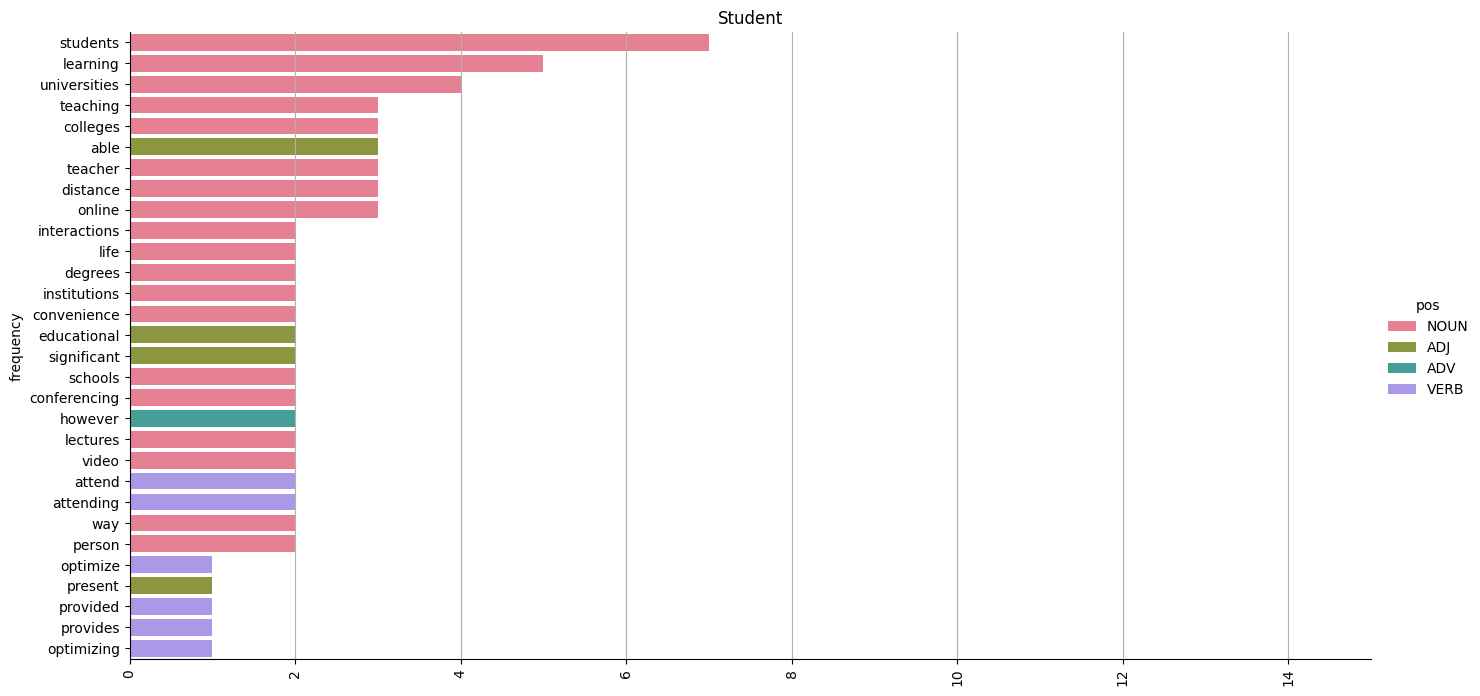

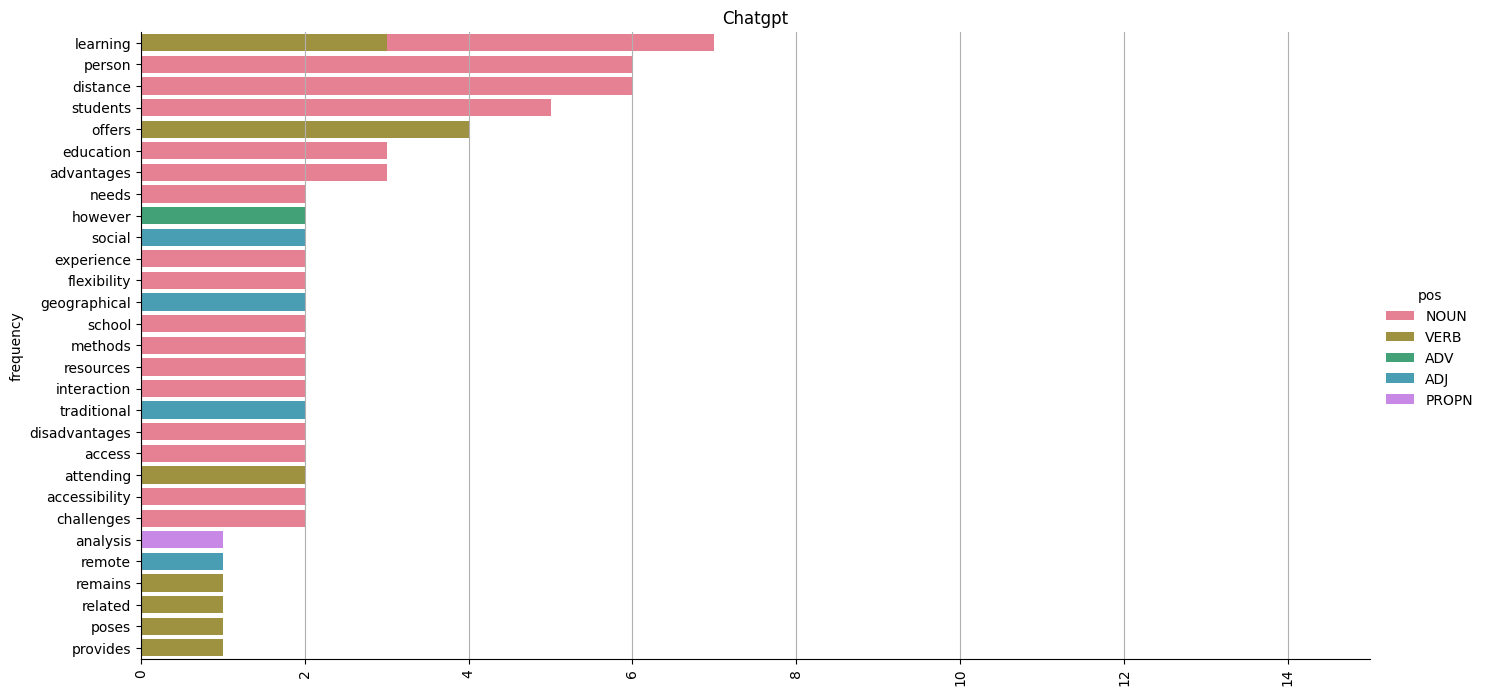

In [16]:
# define which categories we want
content_pos = {"NOUN", "PROPN", "VERB", "ADJ", "ADV"}  # these are "content words"

# filter rows, not columns
student_content_df = student_agg_df[student_agg_df["pos"].isin(content_pos)].reset_index(drop=True) # reset index is not strictly necessary, but it just ensures that our rows are named from 0-134 (try to remove it in your notebook to see the effect)
chatgpt_content_df = chatgpt_agg_df[chatgpt_agg_df["pos"].isin(content_pos)].reset_index(drop=True) 

n_most_frequent = 30
student_plot = plot_frequent_counts(
                            count_df=student_content_df.head(n_most_frequent), 
                            x = "frequency",
                            y = "token",
                            n_most_frequent=n_most_frequent, 
                            title="Student", 
                            xlim=15, 
                            hue="pos"
                            )

chatgpt_plot = plot_frequent_counts(
                            count_df=chatgpt_content_df.head(n_most_frequent), 
                            x = "frequency",
                            y = "token",
                            n_most_frequent=n_most_frequent, 
                            title="Chatgpt", 
                            xlim=15, 
                            hue="pos"
                            )